## Model Evaluation

- ### Import Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
## Load Data
df = pd.read_csv("../data/processed/feature_engineered_flipcart_laptop_data.csv")
df.head()

,Discount price,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
0,54990.0,3.9,7.0,1.0,38.89,MSI,16.0,512.0,SSD,Mid,0,Intel,12,1
1,67990.0,0.0,0.0,0.0,19.05,MSI,8.0,1024.0,SSD,High,0,Intel,12,1
2,35660.0,4.2,1805.0,143.0,27.58,DELL,8.0,512.0,SSD,Entry,0,Intel,12,0
3,26990.0,4.2,6977.0,596.0,38.66,Acer,8.0,512.0,SSD,Entry,0,Intel,11,0
4,27989.0,4.2,1263.0,113.0,52.88,Lenovo,8.0,512.0,SSD,Entry,0,AMD,0,0


In [3]:
target_col = "Discount price"

X = df.drop(columns=[target_col])
y = df[target_col]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train", X_train.shape)
print("Shape of X_test", X_test.shape)
print("Shape of y_train", y_train.shape)
print("Shape of y_test", y_test.shape)

Shape of X_train (738, 13)
Shape of X_test (185, 13)
Shape of y_train (738,)
Shape of y_test (185,)


In [11]:
y_test[:5]

323    57990.0
861    32990.0
30     54990.0
837    27490.0
294    36200.0
Name: Discount price, dtype: float64

- ### Load Final Pipeline

In [6]:
final_pipeline = joblib.load("../artifacts/models/elastic_net_final_model.pkl")
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('yeo_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the outpu

- ### Generate Predictions

In [7]:
y_train_pred = final_pipeline.predict(X_train)

y_test_pred = final_pipeline.predict(X_test)

In [8]:
y_train_pred

array([ 20950.41446067,  32650.45114366, 100112.34177368,  28617.71072092,
        27103.03573455,  57104.90188511,  60326.9059542 ,  35311.8387879 ,
        51595.0333105 ,  99187.40853202,  17038.97159113,  50118.22126134,
        50118.22126134,  53720.74910735,  60326.9059542 ,  36913.116935  ,
        34387.58180269,  99187.40853202,  28617.71072092,  28617.71072092,
        31737.97447561,  35311.8387879 ,  38890.92186059,  36343.15473951,
        33407.08587983,  50118.22126134,  56277.58223462,  17586.44138555,
        72467.85702477,  35311.93721208,  65422.89321713,  43804.12668318,
        74582.07827868,  36344.4076224 ,  53253.80249128,  35311.8387879 ,
        60326.9059542 ,  86304.00143984,  72467.85702477,  36343.15473951,
        28617.71072092,  37590.76672022,  44790.17814611,  30157.59698519,
        49327.47242767,  49143.27670551,  49143.27670551,  67982.76781342,
        54928.32643772,  52204.59719632,  44057.93823425,  19473.48659492,
        63923.50288224,  

In [10]:
y_test_pred[:5]

array([71288.81911588, 40525.25107736, 57104.90188511, 28617.71072092,
       39847.58202845])

- ### Evaluation Function

In [41]:
def evaluate_model(y_true, y_pred):

    # Mean Squared Error
    mse = mean_squared_error(y_true, y_pred)
    # Mean Absolute Error
    mae = mean_absolute_error(y_true, y_pred)
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    # R2 score
    r2 = r2_score(y_true, y_pred)

    return mse, mae, rmse, r2

- ### Training Performance

In [42]:
train_mse, train_mae, train_rmse, train_r2 = evaluate_model(y_train,y_train_pred)

print(f"MSE: {train_mse}")
print(f"MAE: {train_mae}")
print(f"RMSE: {train_rmse}")
print(f"R²: {train_r2}")

MSE: 157238271.63895562
MAE: 7809.122317076928
RMSE: 12539.468554885236
R²: 0.7959707343614961


- ### Testing Performance

In [43]:
test_mse, test_mae, test_rmse, test_r2 = evaluate_model(y_test,y_test_pred)

print(f"MSE: {test_mse}")
print(f"MAE: {test_mae}")
print(f"RMSE: {test_rmse}")
print(f"R²: {test_r2}")

MSE: 396576215.78261256
MAE: 9578.24293003407
RMSE: 19914.22144555525
R²: 0.776807507761827


- ### Performance Summary Table

In [44]:
evaluation_df = pd.DataFrame({

    "Metric": [
        "R² Score",
        "MAE",
        "RMSE"
    ],

    "Train Set": [
        train_r2,
        train_mae,
        train_rmse
    ],

    "Test Set": [
        test_r2,
        test_mae,
        test_rmse
    ]
})

evaluation_df

,Metric,Train Set,Test Set
0,R² Score,0.795971,0.776808
1,MAE,7809.122317,9578.242930
2,RMSE,12539.468555,19914.221446


- ### Actual vs Predicted Plot

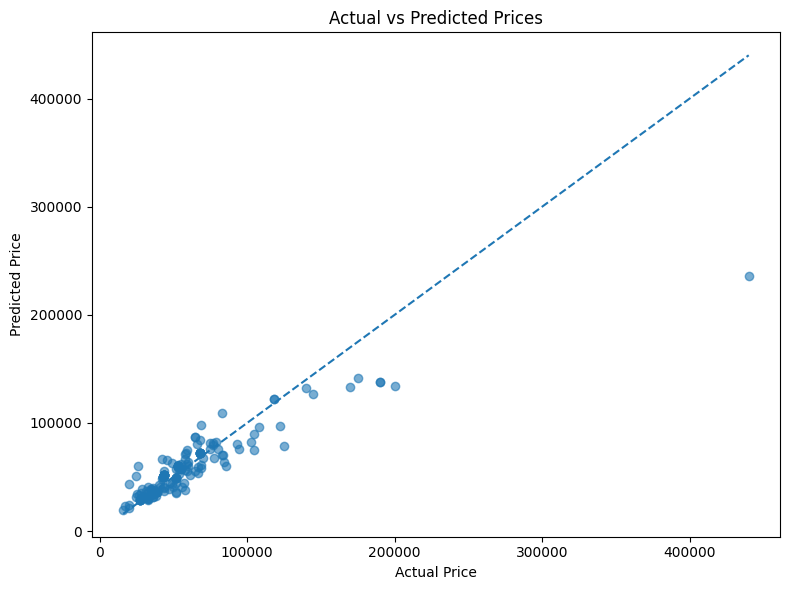

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.tight_layout()

plt.show()

##### Business Insight:
- Points closer to the diagonal line indicate better prediction accuracy.

- ### Residual Analysis

In [46]:
residuals = y_test - y_test_pred

#### Residual Distribution

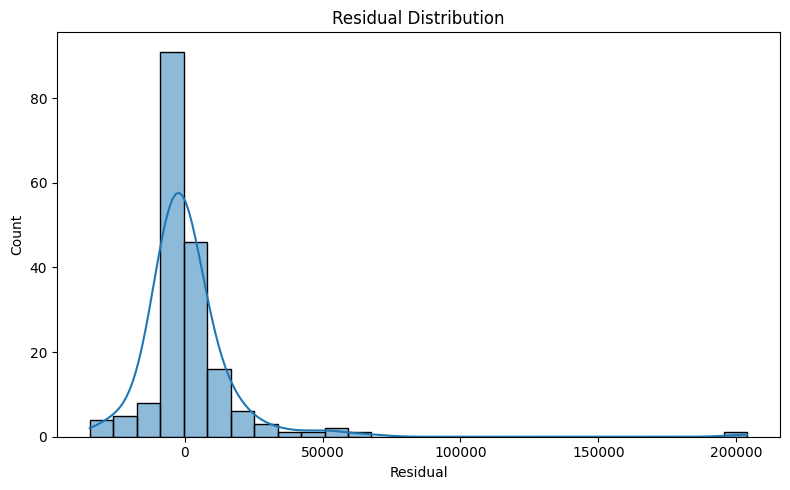

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

## Add title
plt.title("Residual Distribution")
## Add Xlable
plt.xlabel("Residual")

plt.tight_layout()

plt.show()

##### Business Insight:
- A roughly normal residual distribution indicates the model is not systematically biased.

- ### Residual Scatter Plot

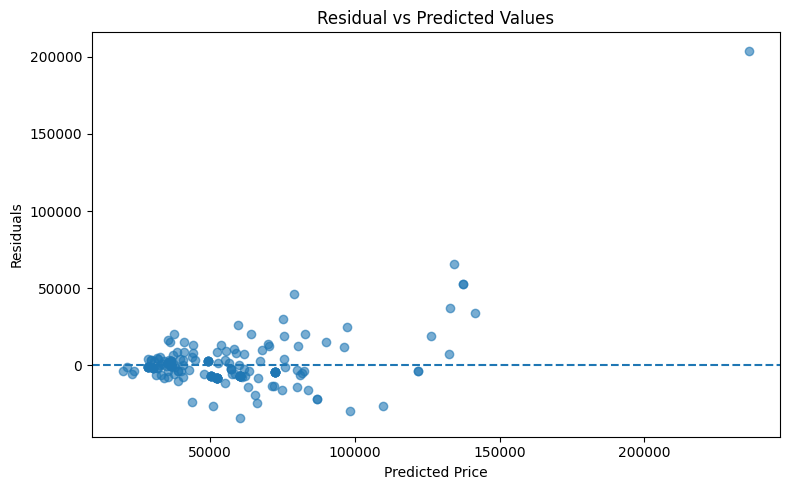

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(y_test_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

## Add xlable
plt.xlabel("Predicted Price")
## Add ylable
plt.ylabel("Residuals")
## Add title
plt.title("Residual vs Predicted Values")

plt.tight_layout()

plt.show()

##### Business Insight:
- Random residual distribution indicates stable model predictions.

- ### Extract ElasticNet Coefficients

In [49]:
elastic_net = final_pipeline.named_steps["model"].regressor_

In [50]:
coefficients = elastic_net.coef_
print(coefficients)

[-0.00000000e+00 -3.14425109e-02  1.44483504e-01  6.35037033e-02
 -1.06639733e-01 -1.65387527e-02  8.85473188e-06 -1.47802381e-01
  5.11932833e-02 -8.71979304e-02  1.49481964e-01  1.46792056e-01
  1.41998488e-02 -5.94795604e-02]


In [51]:
feature_names = [

    # Numeric Pipeline
    "Rating",
    "Reviews",
    "ram_gb",
    "storage_gb",
    "discount_pct(%)",

    # Yeo Pipeline
    "Stars",

    # Target Encoder
    "brand",

    # OneHot Encoder
    "storage_type_HDD",
    "storage_type_SSD",
    "processor_brand_Intel",

    # Ordinal Encoder
    "processor_tier",

    # Passthrough
    "is_gaming",
    "processor_generation",
    "premium_brand"
]

In [52]:
elastic_net = (
    final_pipeline
    .named_steps["model"]
    .regressor_
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": elastic_net.coef_
})

coef_df["Absolute_Coefficient"] = (
    coef_df["Coefficient"].abs()
)

coef_df = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
10,processor_tier,0.149482,0.149482
7,storage_type_HDD,-0.147802,0.147802
11,is_gaming,0.146792,0.146792
2,ram_gb,0.144484,0.144484
4,discount_pct(%),-0.106640,0.106640
9,processor_brand_Intel,-0.087198,0.087198
3,storage_gb,0.063504,0.063504
13,premium_brand,-0.059480,0.059480
8,storage_type_SSD,0.051193,0.051193
1,Reviews,-0.031443,0.031443


- ### Plot Coefficients

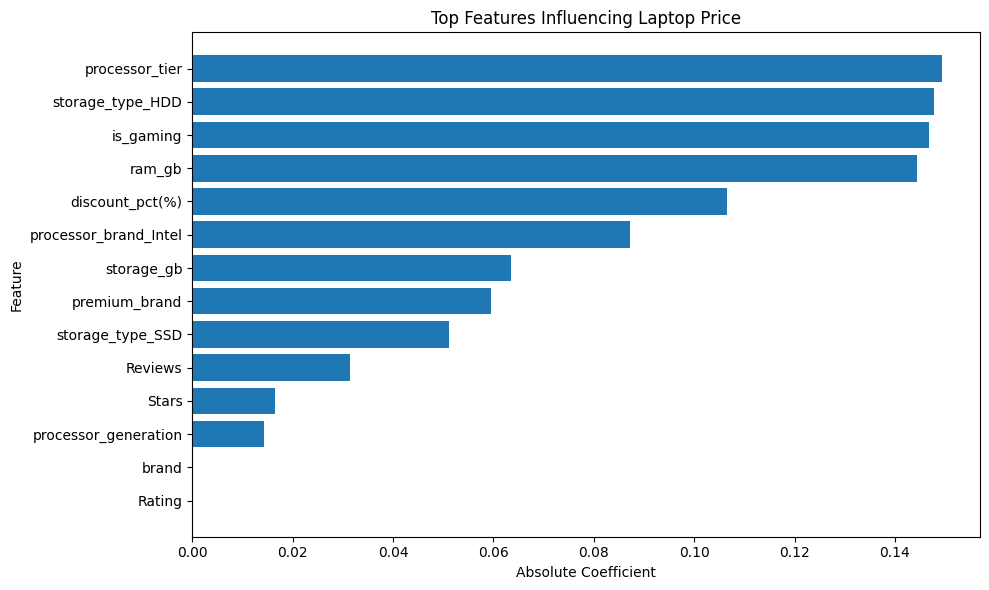

In [53]:
plt.figure(figsize=(10,6))

top_features = (
    coef_df
    .head(14)
    .sort_values(
        by="Absolute_Coefficient",
        ascending=True
    )
)

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Laptop Price")

plt.tight_layout()
plt.show()

##### Business Insight:
- Features with larger absolute coefficients have greater influence on laptop pricing.

- ### Save Results

In [ ]:
# evaluation_df.to_csv("../artifacts/reports/model_evaluation.csv",index=False)

# coef_df.to_csv("../artifacts/reports/elasticnet_coefficients.csv", index=False)

- ### Final Conclusion

In [55]:
print("Final Model: ElasticNet")
print(f"Train R² : {train_r2:.4f}")
print(f"Test R²  : {test_r2:.4f}")
print("Cross Validation Mean R² : 0.7688")
print("Cross Validation Std R²  : 0.0425")

Final Model: ElasticNet
Train R² : 0.7960
Test R²  : 0.7768
Cross Validation Mean R² : 0.7688
Cross Validation Std R²  : 0.0425
